# Financial Literacy DDC — Run & Stats
This notebook runs the structural estimation and reproduces lecture-style summary stats.

**Choose a method below (NFXP or NPL)**, run the solver, then load outputs and compare to the data.

In [1]:
# Configuration
DATA_PATH = 'synthetic_finlit_portfolio.csv'  # path to your panel CSV
METHOD = 'nfxp'  # 'nfxp' or 'npl'

# Estimation options
KA, KY, KL, KAGE = 5, 5, 3, 3
BETA, RF, MUR, SDR = 0.96, 0.01, 0.05, 0.15
SIGMA = 2.0  # used by NFXP; NPL keeps sigma fixed here
RISK_GRID = '0,0.25,0.5,0.75,1.0'
SAVE_GRID = '0,0.1,0.2,0.3,0.4,0.5'
F0_START, PHI_START = 25.0, 10.0  # NPL only

## 1) Run estimation from the notebook
This will spawn the appropriate solver as a subprocess.

In [2]:
import subprocess, sys
if METHOD == 'nfxp':
    cmd = [sys.executable, 'Solve_NFXP.py', '--data', DATA_PATH,
           '--Ka', str(KA), '--Ky', str(KY), '--KL', str(KL), '--Kage', str(KAGE),
           '--beta', str(BETA), '--rf', str(RF), '--muR', str(MUR), '--sdR', str(SDR),
           '--sigma0', str(SIGMA), '--risk_grid', RISK_GRID, '--save_grid', SAVE_GRID]
else:
    cmd = [sys.executable, 'Solve_NPL.py', '--data', DATA_PATH,
           '--Ka', str(KA), '--Ky', str(KY), '--KL', str(KL), '--Kage', str(KAGE),
           '--beta', str(BETA), '--rf', str(RF), '--muR', str(MUR), '--sdR', str(SDR),
           '--sigma', str(SIGMA), '--F0_start', str(F0_START), '--phi_start', str(PHI_START),
           '--risk_grid', RISK_GRID, '--save_grid', SAVE_GRID]

print('Running:', ' '.join(cmd))
subprocess.run(cmd, check=True)
print('Estimation complete.')

Running: /opt/anaconda3/envs/data_science/bin/python Solve_NFXP.py --data synthetic_finlit_portfolio.csv --Ka 5 --Ky 5 --KL 3 --Kage 3 --beta 0.96 --rf 0.01 --muR 0.05 --sdR 0.15 --sigma0 2.0 --risk_grid 0,0.25,0.5,0.75,1.0 --save_grid 0,0.1,0.2,0.3,0.4,0.5


/Users/mac/Desktop/Projects/AaltoCourse_exercises/my_testing/finlit_sol/lecture_style/model_finlit.py:221: RuntimeWarning: divide by zero encountered in matmul
  EV = Pi @ V
/Users/mac/Desktop/Projects/AaltoCourse_exercises/my_testing/finlit_sol/lecture_style/model_finlit.py:221: RuntimeWarning: overflow encountered in matmul
  EV = Pi @ V
/Users/mac/Desktop/Projects/AaltoCourse_exercises/my_testing/finlit_sol/lecture_style/model_finlit.py:221: RuntimeWarning: invalid value encountered in matmul
  EV = Pi @ V
/Users/mac/Desktop/Projects/AaltoCourse_exercises/my_testing/finlit_sol/lecture_style/model_finlit.py:227: RuntimeWarning: divide by zero encountered in matmul
  Q = U + beta * (Pi @ V)
/Users/mac/Desktop/Projects/AaltoCourse_exercises/my_testing/finlit_sol/lecture_style/model_finlit.py:227: RuntimeWarning: overflow encountered in matmul
  Q = U + beta * (Pi @ V)
/Users/mac/Desktop/Projects/AaltoCourse_exercises/my_testing/finlit_sol/lecture_style/model_finlit.py:227: RuntimeWarni

NFXP done: {'parameter': ['sigma', 'F0', 'phi'], 'estimate': [0.5269497970311646, 12.414660753373639, 156.96023114823134]}
Estimation complete.


## 2) Load outputs and show estimates

In [3]:
import numpy as np, pandas as pd
from pathlib import Path

est_path = Path(f'finlit_estimates_{METHOD}.csv')
V_path = Path(f'V_hat_{METHOD}.npy')
CCP_path = Path(f'CCP_hat_{METHOD}.npy')
policy_path = Path(f'policy_{METHOD}.csv')

est = pd.read_csv(est_path)
V = np.load(V_path)
CCP = np.load(CCP_path)
policy = pd.read_csv(policy_path)
display(est)
print('V shape:', V.shape, ' | CCP shape:', CCP.shape)
policy.head()

,parameter,estimate
0,sigma,0.526950
1,F0,12.414661
2,phi,156.960231


V shape: (225,)  | CCP shape: (225, 36)


,state,policy_obs_idx
0,"(0, 0, 0, 0)",0
1,"(0, 0, 0, 1)",3
2,"(0, 0, 0, 2)",4
3,"(0, 0, 1, 0)",4
4,"(0, 0, 1, 1)",4


## 3) Compare to the data (wave 1)
We compute observed participation and risky-share distribution in the raw data and compare with the model **policy**.

In [4]:
import pandas as pd
df = pd.read_csv(DATA_PATH)
w1 = df[df['wave']==1].copy()
obs_part_rate = w1['participate_risky'].mean()

# Discretize observed risky shares to the grid used by solvers
risk_grid = [float(x) for x in RISK_GRID.split(',')]
def nearest(val, grid):
    import math
    return grid[int(np.argmin([abs(val-g) for g in grid]))]
w1['r_share_disc'] = w1['risky_share'].apply(lambda v: nearest(v, risk_grid))

obs_dist = w1.groupby(['participate_risky','r_share_disc']).size().reset_index(name='n')
obs_dist['share'] = obs_dist['n'] / obs_dist['n'].sum()
obs_dist.head()

,participate_risky,r_share_disc,n,share
0,0,0.00,125,0.078125
1,1,0.50,4,0.002500
2,1,0.75,48,0.030000
3,1,1.00,1423,0.889375


### Model-implied participation & risky-share distribution (policy)

In [5]:
import numpy as np, pandas as pd
# policy_obs_idx: 0 -> (d=0,k=0); 1.. -> (d=1,k=risk_grid[i-1])
idx = policy['policy_obs_idx'].to_numpy() if 'policy_obs_idx' in policy.columns else policy['policy_idx'].to_numpy()
part_rate_model = float(np.mean(idx != 0))

labels = [(0,0.0)] + [(1,k) for k in risk_grid]
counts = np.array([np.mean(idx==j) for j in range(len(labels))])
model_dist = pd.DataFrame({
    'participate_risky':[d for d,k in labels],
    'r_share_disc':[k for d,k in labels],
    'share':counts
})
model_dist.head()

,participate_risky,r_share_disc,share
0,0,0.00,0.044444
1,1,0.00,0.000000
2,1,0.25,0.000000
3,1,0.50,0.013333
4,1,0.75,0.297778


### Side-by-side summary table

In [6]:
summary = pd.DataFrame({
    'metric':['Participation rate (data)','Participation rate (model policy)'],
    'value':[obs_part_rate, part_rate_model]
})
display(summary)

# Risky-share distribution among participants only
obs_dist_part = obs_dist[obs_dist['participate_risky']==1].groupby('r_share_disc')['share'].sum()
model_dist_part = model_dist[model_dist['participate_risky']==1].set_index('r_share_disc')['share']
comp_k = pd.concat([obs_dist_part.rename('data'), model_dist_part.rename('model')], axis=1).fillna(0.0)
comp_k.index.name = 'risky_share_disc'
comp_k.reset_index()

,metric,value
0,Participation rate (data),0.921875
1,Participation rate (model policy),0.955556


,risky_share_disc,data,model
0,0.50,0.002500,0.013333
1,0.75,0.030000,0.297778
2,1.00,0.889375,0.644444
3,0.00,0.000000,0.000000
4,0.25,0.000000,0.000000


## 4) Lecture-style plots (matplotlib only)

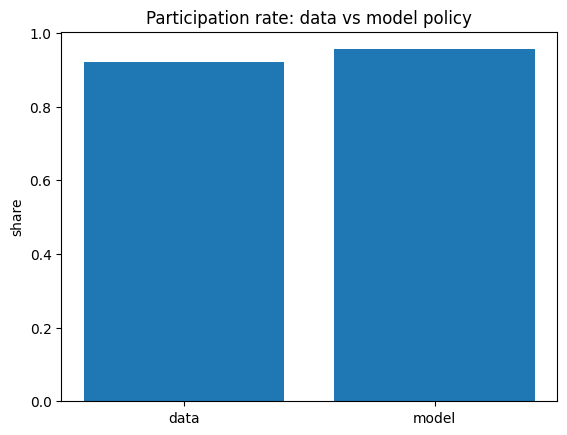

In [7]:
import matplotlib.pyplot as plt

# Participation rates
plt.figure()
plt.bar(['data','model'], [obs_part_rate, part_rate_model])
plt.title('Participation rate: data vs model policy')
plt.xlabel('')
plt.ylabel('share')
plt.show()

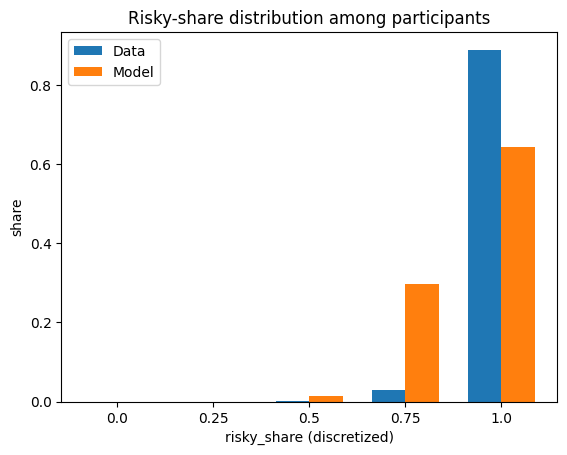

In [10]:
# Risky-share among participants
plt.figure()
xs = [str(k) for k in sorted(set(risk_grid))]
data_vals = [comp_k.loc[float(k),'data'] if float(k) in comp_k.index else 0.0 for k in xs]
model_vals = [comp_k.loc[float(k),'model'] if float(k) in comp_k.index else 0.0 for k in xs]
width = 0.35
pos = np.arange(len(xs))
plt.bar(pos - width/2, data_vals, width)
plt.bar(pos + width/2, model_vals, width)
plt.title('Risky-share distribution among participants')
plt.xlabel('risky_share (discretized)')
plt.ylabel('share')
plt.xticks(pos, xs)
plt.legend(["Data","Model"])
plt.show()

## 5) Inspect a few states with extreme policies

In [11]:
policy['participate'] = (policy['policy_obs_idx'] if 'policy_obs_idx' in policy.columns else policy['policy_idx']) != 0
most_part = policy.sample(10, random_state=1)
display(most_part)
print('Total states:', len(policy))

,state,policy_obs_idx,participate
39,"(0, 4, 1, 0)",5,True
166,"(3, 3, 1, 1)",5,True
93,"(2, 0, 1, 0)",4,True
62,"(1, 1, 2, 2)",4,True
195,"(4, 1, 2, 0)",5,True
119,"(2, 3, 0, 2)",5,True
38,"(0, 4, 0, 2)",5,True
184,"(4, 0, 1, 1)",5,True
160,"(3, 2, 2, 1)",5,True
89,"(1, 4, 2, 2)",5,True


Total states: 225
